# **3. Transfer Learning and Fine-Tuning**

## **Data Preprocessing and Preparation**

### **Imports**

In [1]:
from google.colab import drive
import sys, os
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import random
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
import time
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import accuracy_score, balanced_accuracy_score
import shutil
import numpy as np
from PIL import Image
from collections import Counter
from scipy.stats import entropy
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import label_binarize, LabelEncoder
from sklearn.metrics import roc_curve, auc
from torchvision import transforms
from skimage.measure import shannon_entropy
import cv2
from skimage.feature import local_binary_pattern
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torchvision import models

### **Load Dataset and Images**

In [2]:
drive.mount('/content/drive', force_remount=True)

DRIVE_BASE = '/content/drive/MyDrive/pokemon_dataset'
LOCAL_BASE = '/content/pokemon_dataset'

if os.path.exists(LOCAL_BASE):
    print("Removing incomplete local dataset...")
    shutil.rmtree(LOCAL_BASE)

print("Copying dataset from Drive to local storage...")
shutil.copytree(DRIVE_BASE, LOCAL_BASE)
print("Done!")

BASE = LOCAL_BASE

Mounted at /content/drive
Copying dataset from Drive to local storage...
Done!


In [3]:
#Changing to GPU
#Changing from CPU to GPU manualmente -> Alterar tipo de tempo de execução -> T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


### **Image transformation**

In [4]:
#Image normalization -> (224x224)

#The pre trained models use this dimenstions from ImageNet to learn
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

#Standart for most models
img_size = 224

In [5]:
basic_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.Resize(256),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),])

## **EDA**

In [6]:
#Counts of images for each class
sys.path.append(BASE)
import CustomImageDataset as CID

train_dataset = CID.CustomImageDataset(
    annotations_file=f'{BASE}/train_labels.csv',
    img_dir=f'{BASE}/train/',
    transform=basic_transform)

test_dataset = CID.CustomImageDataset(
    img_dir=f'{BASE}/test/',
    transform=basic_transform)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

NUM_CLASSES = len(train_dataset.classes)
print(f'\nTrain: {len(train_dataset)} imagens')
print(f'Test  : {len(test_dataset)} imagens')
print(f'Number of unique classes: {len(train_dataset.classes)}')
print(f'Classes: {train_dataset.classes}')

counts = train_dataset.df['label'].value_counts().sort_index()
total  = len(train_dataset)

class_dist = pd.DataFrame({
    'Label':          counts.index,
    'Count':          counts.values,
    'Percentage(%)':  (counts.values / total * 100).round(2)
}).sort_values(by="Count", ascending=False)

print("Class Distribution Summary:")
print(class_dist.to_string(index=False))

print(f"\nMost common: {counts.idxmax()} ({counts.max()} samples, {(counts.max()/total*100):.2f}%)")
print(f"Least common: {counts.idxmin()} ({counts.min()} samples, {(counts.min()/total*100):.2f}%)")


Train: 1194 imagens
Test  : 300 imagens
Number of unique classes: 9
Classes: ['Bug', 'Fighting', 'Fire', 'Grass', 'Ground', 'Normal', 'Poison', 'Rock', 'Water']
Class Distribution Summary:
   Label  Count  Percentage(%)
   Water    252          21.11
  Normal    222          18.59
   Grass    159          13.32
     Bug    150          12.56
    Fire    114           9.55
    Rock     99           8.29
  Ground     72           6.03
  Poison     66           5.53
Fighting     60           5.03

Most common: Water (252 samples, 21.11%)
Least common: Fighting (60 samples, 5.03%)


In [7]:
#Proportion of images per class in train and validation
labels = train_dataset.df['label'].tolist()

train_idx, val_idx = train_test_split(
    range(len(train_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42
)

train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(train_dataset, val_idx)

# Smaller batch for CNN (more GPU memory per sample vs MLP)
train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_subset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Treino    : {len(train_subset)} imagens")
print(f"Validação : {len(val_subset)} imagens")

train_labels = [train_dataset.df.iloc[i]['label'] for i in train_idx]
val_labels   = [train_dataset.df.iloc[i]['label'] for i in val_idx]

comparison = pd.DataFrame({
    'Treino':    pd.Series(train_labels).value_counts(normalize=True).round(3) * 100,
    'Validação': pd.Series(val_labels).value_counts(normalize=True).round(3) * 100,
}).sort_values(by='Treino', ascending=False)

print(comparison)

Treino    : 955 imagens
Validação : 239 imagens
          Treino  Validação
Water       21.0       21.3
Normal      18.6       18.4
Grass       13.3       13.4
Bug         12.6       12.6
Fire         9.5        9.6
Rock         8.3        8.4
Ground       6.1        5.9
Poison       5.5        5.4
Fighting     5.0        5.0


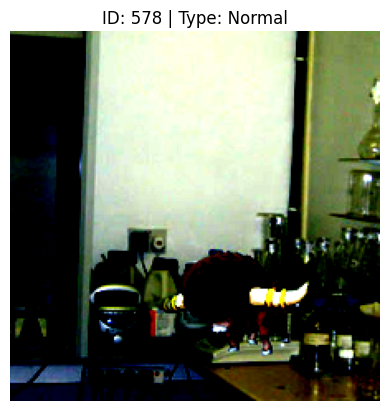

In [8]:
#Random image from train dataset
idx = random.randint(0, len(train_dataset) - 1)
image, label = train_dataset[idx]

image = image.permute(1, 2, 0)  #Changes the order of dimensions to plt because it's set to pyTorch by default.

plt.imshow(image)
plt.title(f'ID: {idx} | Type: {train_dataset.classes[label]}')
plt.axis('off')
plt.show()

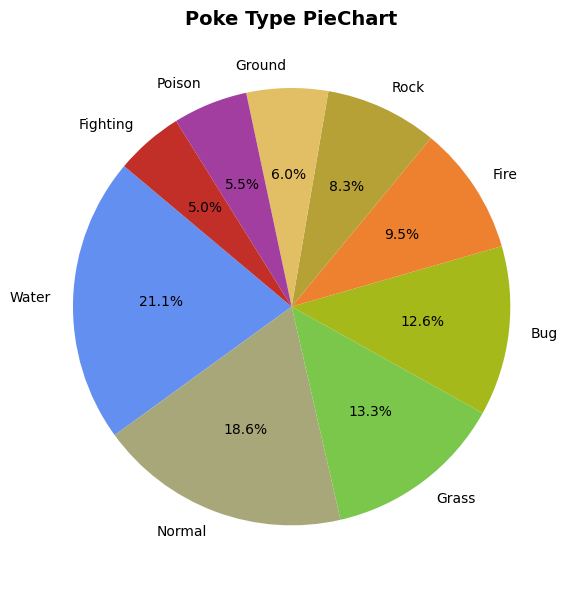

In [9]:
#Piechart of Pokemon type
type_colors = {
    'Bug':      '#A6B91A',
    'Fighting': '#C22E28',
    'Fire':     '#EE8130',
    'Grass':    '#7AC74C',
    'Ground':   '#E2BF65',
    'Normal':   '#A8A77A',
    'Poison':   '#A33EA1',
    'Rock':     '#B6A136',
    'Water':    '#6390F0',
}

labels  = class_dist['Label'].tolist()
counts  = class_dist['Count'].tolist()
colors  = [type_colors.get(l, '#888888') for l in labels]  #Grey if the type doesn´t exist

plt.figure(figsize=(8, 6))
plt.pie(
    counts,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140
)
plt.title('Poke Type PieChart', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Imbalance ratio
counts = np.array(class_dist['Count'].tolist())

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance Ratio (Max/Min): {imbalance_ratio:.2f}")

class_probs = counts / total
entropy_value = entropy(class_probs)
normalized_entropy = entropy_value / np.log(len(counts))
print(f"Entropy: {normalized_entropy:.4f}")

# Gini (0 to 0.8889)
gini = 1 - np.sum(class_probs ** 2)
print(f"Gini Index: {gini:.4f}")

Imbalance Ratio (Max/Min): 4.20
Entropy: 0.9469
Gini Index: 0.8622


In [11]:
# Obtain information about the columns
print(train_dataset.df.columns)
print(train_dataset.df.head())

Index(['Id', 'label'], dtype='object')
                                     Id  label
0  6702e55d-8172-492a-8f87-a3da277b53a7  Water
1  f93ea8ca-a4ad-475a-9c2a-12baaace2992  Water
2  be649239-3880-4369-846d-8030b182d18e  Water
3  cc812e42-37e1-40c5-a49f-60eafd030943  Water
4  e2af2db9-2978-4274-824a-13cb62b8c08c  Water


Mean (R, G, B): [0.4931 0.4338 0.3753]
Std  (R, G, B): [0.2385 0.2356 0.2315]


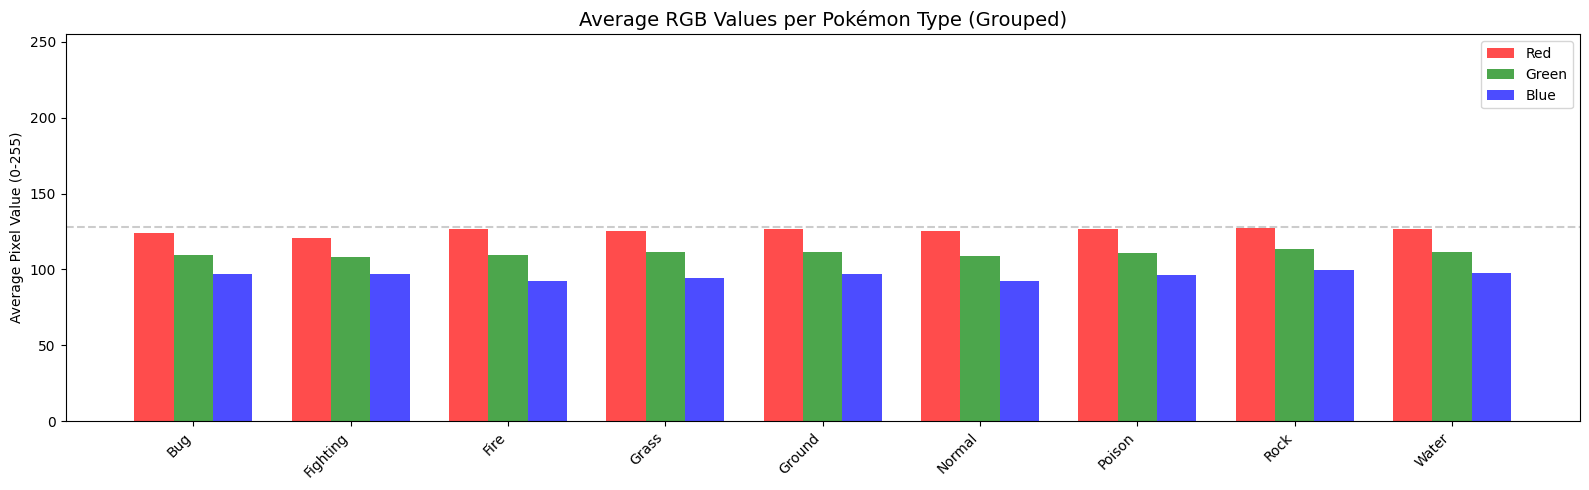

In [12]:
#Red, Green and Blue
def compute_mean_std(dataset):
    means, stds = [], []
    for img_id in dataset.df['Id']:
        path = f'{BASE}/train/{img_id}.png'
        if os.path.exists(path):
            img = np.array(Image.open(path).convert('RGB')) / 255.0
            means.append(img.mean(axis=(0,1)))
            stds.append(img.std(axis=(0,1)))
    means = np.array(means).mean(axis=0)
    stds  = np.array(stds).mean(axis=0)
    print(f"Mean (R, G, B): {means.round(4)}")
    print(f"Std  (R, G, B): {stds.round(4)}")

compute_mean_std(train_dataset)

def avg_color_per_type(dataset):
    type_colors = {}
    for ptype in dataset.df['label'].unique():
        subset = dataset.df[dataset.df['label'] == ptype]
        rgbs = [np.array(Image.open(f'{BASE}/train/{img_id}.png').convert('RGB')).mean(axis=(0,1))
                for img_id in subset['Id'] if os.path.exists(f'{BASE}/train/{img_id}.png')]
        if rgbs:
            type_colors[ptype] = np.array(rgbs).mean(axis=0)

    types  = sorted(type_colors.keys())
    r_vals = [type_colors[t][0] for t in types]
    g_vals = [type_colors[t][1] for t in types]
    b_vals = [type_colors[t][2] for t in types]

    x = np.arange(len(types))
    width = 0.25
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.bar(x - width, r_vals, width, color='red',   alpha=0.7, label='Red')
    ax.bar(x,         g_vals, width, color='green', alpha=0.7, label='Green')
    ax.bar(x + width, b_vals, width, color='blue',  alpha=0.7, label='Blue')
    ax.set_xticks(x)
    ax.set_xticklabels(types, rotation=45, ha='right')
    ax.set_title('Average RGB Values per Pokémon Type (Grouped)', fontsize=14)
    ax.set_ylabel('Average Pixel Value (0-255)')
    ax.legend()
    ax.set_ylim(0, 255)
    ax.axhline(128, color='gray', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

avg_color_per_type(train_dataset)

In [13]:
# Missing values
missing = [img_id for img_id in train_dataset.df['Id']
           if not os.path.exists(f'{BASE}/train/{img_id}.png')]
print(f"Imagens em falta: {len(missing)}")

# Duplicates
print(f"IDs duplicados: {train_dataset.df['Id'].duplicated().sum()}")

# Resolutions
sizes = Counter(Image.open(f'{BASE}/Train/{img_id}.png').size
                for img_id in train_dataset.df['Id']
                if os.path.exists(f'{BASE}/Train/{img_id}.png'))
print(f"Resoluções distintas: {len(sizes)} → {dict(sizes)}")

Imagens em falta: 0
IDs duplicados: 0
Resoluções distintas: 0 → {}


### **Laplacian variance**

Laplacian variance is used as a simple, fast metric to estimate image sharpness vs. noise in a dataset.
In a noisy dataset, its main purposes are:
- Blur detection: The Laplacian operator highlights edges. If the variance is low, the image is likely blurred (few strong edges).
- Quality filtering: Helps remove low-quality or out-of-focus samples before training.
- Noise sensitivity check: High variance can indicate either sharp detail or excessive noise, so it helps flag potentially corrupted samples.
- Preprocessing decision: Guides whether denoising or sharpening should be applied.

Sharpness (Laplacian Variance) — mean: 1559.67, std: 1464.58


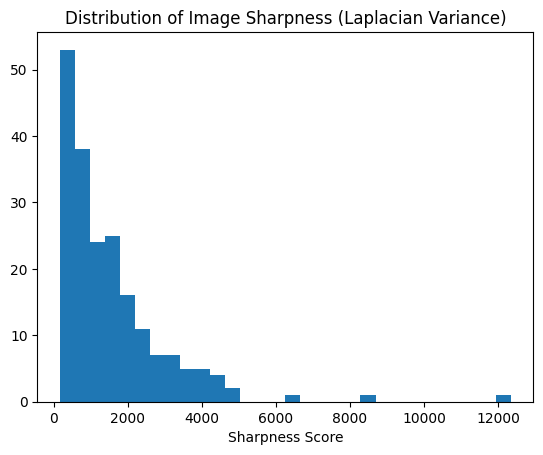

In [14]:
def analyze_noise(dataset, n=200):
    scores = []
    for img_id in dataset.df['Id'].sample(n):
        img = np.array(Image.open(f'{BASE}/train/{img_id}.png').convert('RGB'))
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        lap_var = cv2.Laplacian(gray, cv2.CV_64F).var()
        scores.append(lap_var)

    print(f"Sharpness (Laplacian Variance) — mean: {np.mean(scores):.2f}, std: {np.std(scores):.2f}")
    plt.hist(scores, bins=30)
    plt.title("Distribution of Image Sharpness (Laplacian Variance)")
    plt.xlabel("Sharpness Score")
    plt.show()
analyze_noise(train_dataset)

### **Resolutions**

Image resolution check is used to quickly understand the size distribution of images in a dataset.


In [15]:
def check_resolutions(dataset, n=300):
    sizes = []
    for img_id in dataset.df['Id'].sample(n):
        path = f'{BASE}/train/{img_id}.png'
        if os.path.exists(path):
            img = Image.open(path)
            sizes.append(img.size)
    widths, heights = zip(*sizes)
    print(f"Width  — mean: {np.mean(widths):.0f}, min: {min(widths)}, max: {max(widths)}")
    print(f"Height — mean: {np.mean(heights):.0f}, min: {min(heights)}, max: {max(heights)}")

check_resolutions(train_dataset)

Width  — mean: 400, min: 400, max: 400
Height — mean: 300, min: 300, max: 300


### **Texture complexity (via LBP variance)**

Is used to estimate how visually detailed or patterned images are across different classes.
In a noisy dataset, its main purposes are:
- Measure texture richness: Higher variance → more complex patterns (edges, micro-textures).
- Class separability insight: Some classes may have distinct texture complexity, helping classification.
- Detect noisy classes: Unusually high variance can indicate noise/artifacts rather than meaningful texture.
- Guide preprocessing: Helps decide if smoothing, denoising, or feature extraction (e.g., texture-based models) is needed.
- Model strategy: Indicates whether texture features will be useful for learning.

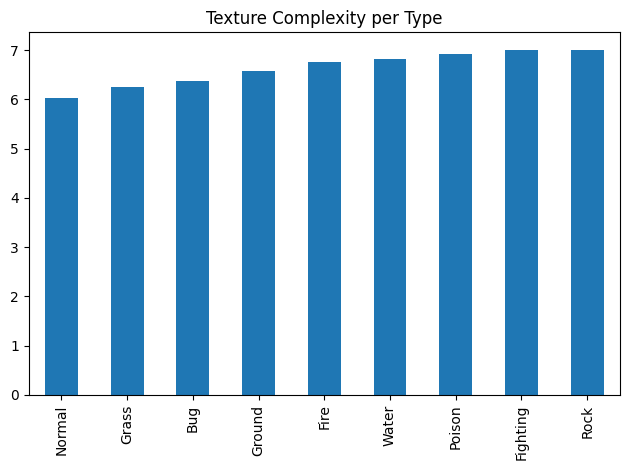

In [16]:
def texture_complexity(dataset, n=150):
    scores_per_type = {}
    for ptype in dataset.df['label'].unique():
        subset = dataset.df[dataset.df['label'] == ptype].sample(min(20, len(dataset.df[dataset.df['label'] == ptype])))
        scores = []
        for img_id in subset['Id']:
            img = np.array(Image.open(f'{BASE}/train/{img_id}.png').convert('L'))
            lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
            scores.append(lbp.var())
        scores_per_type[ptype] = np.mean(scores)
    pd.Series(scores_per_type).sort_values().plot(kind='bar', title='Texture Complexity per Type')
    plt.tight_layout(); plt.show()

texture_complexity(train_dataset)

### **t-SNE (on raw pixel features)**

Is used to visualize how images are distributed and clustered in feature space.
In a noisy dataset, its main purposes are:
- Class separability check: Shows if different labels form distinct clusters or overlap.
- Noise detection: Scattered or mixed points may indicate mislabeled or noisy samples.
- Data structure insight: Reveals hidden patterns or similarities between classes.
- Outlier identification: Isolated points can signal corrupted or unusual images.
- Model feasibility: If clusters are well-separated, the task is likely easier for a model.

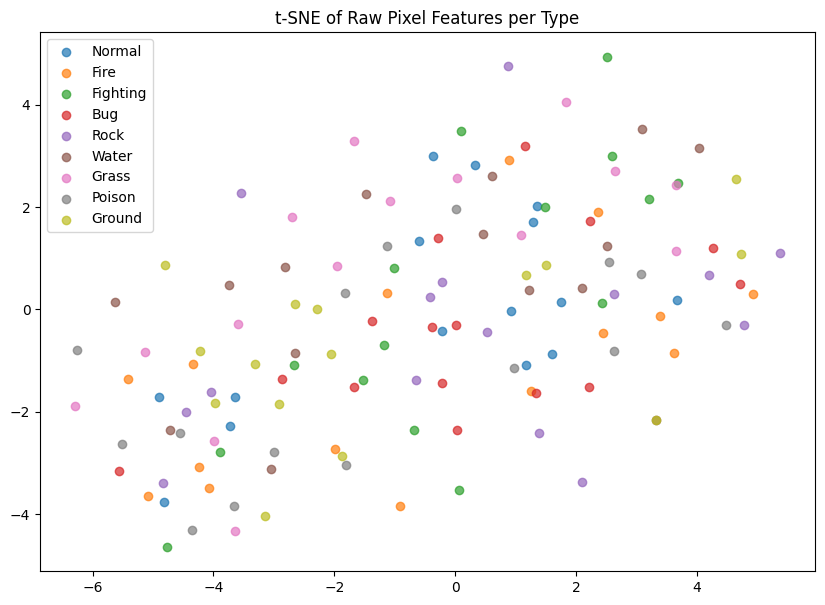

In [17]:
def plot_tsne(dataset, n_per_class=15):
    feats, lbls = [], []
    for ptype in dataset.df['label'].unique():
        subset = dataset.df[dataset.df['label'] == ptype].sample(n_per_class)
        for img_id in subset['Id']:
            img = np.array(Image.open(f'{BASE}/train/{img_id}.png').convert('RGB').resize((32,32))).flatten() / 255.
            feats.append(img); lbls.append(ptype)
    X_2d = TSNE(n_components=2, random_state=42).fit_transform(np.array(feats))
    plt.figure(figsize=(10,7))
    for ptype in set(lbls):
        mask = [l == ptype for l in lbls]
        plt.scatter(X_2d[mask,0], X_2d[mask,1], label=ptype, alpha=0.7)
    plt.legend(); plt.title("t-SNE of Raw Pixel Features per Type"); plt.show()

plot_tsne(train_dataset)

## **Data Division**

In [18]:
labels = train_dataset.df['label'].tolist()
train_idx, val_idx = train_test_split(
    range(len(train_dataset)),
    test_size=0.2,
    stratify=labels,
    random_state=42)

train_subset = Subset(train_dataset, train_idx)
val_subset   = Subset(train_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_subset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

## **Adding Weigths by classes**

We used class weights:

$w_c = \sqrt{\frac{N}{n_c}}$

where $N$ is the total number of training samples and $n_c$ is the number of samples in class $c$.

In [19]:
train_labels  = [train_dataset.df.iloc[i]['label'] for i in train_idx]
train_series  = pd.Series(train_labels)
class_counts  = train_series.value_counts()

weights_list = [
    (len(train_labels) / class_counts[cls]) ** 0.5
    for cls in train_dataset.classes
]
class_weights = torch.tensor(weights_list, dtype=torch.float32).to(device)

print("Class weights:")
for cls, w in zip(train_dataset.classes, class_weights):
    print(f"{cls:<12}count:{class_counts[cls]:>4}; weight:{w:.3f}")

Class weights:
Bug         count: 120; weight:2.821
Fighting    count:  48; weight:4.460
Fire        count:  91; weight:3.240
Grass       count: 127; weight:2.742
Ground      count:  58; weight:4.058
Normal      count: 178; weight:2.316
Poison      count:  53; weight:4.245
Rock        count:  79; weight:3.477
Water       count: 201; weight:2.180


# **3.1 Model Selection and Justification**

The selection of EfficientNet-B0, EfficientNet-B2, and ResNet-50 as candidate models for this transfer learning task is well-grounded in both the dataset characteristics revealed by the EDA and the empirical results obtained during the baseline (frozen backbone) evaluation phase.

The dataset consists of 1,194 training images distributed across 9 Pokémon type classes (Bug, Fighting, Fire, Grass, Ground, Normal, Poison, Rock, Water), with a significant class imbalance ratio of 4.20 (Water: 252 samples vs. Fighting: 60 samples). The normalized entropy of 0.9469 and a Gini index of 0.8622 confirm moderate-to-high imbalance, which necessitates models robust to skewed distributions — a strength of all three selected architectures when combined with weighted loss functions, as already implemented in this work.

The dataset is also relatively small by deep learning standards (955 training, 239 validation samples), which makes the use of pre-trained ImageNet backbones especially justified: the rich feature representations already learned from millions of images allow the models to generalise effectively even with limited task-specific data.

All images are uniformly sized at 400×300 pixels and are PNG files with no missing values or duplicate IDs, indicating a clean dataset. The Laplacian variance analysis (mean: 1515.54, std: 1333.56) reveals high sharpness variability, meaning some images are significantly more detailed than others. This favours architectures with strong multi-scale feature extraction capabilities. EfficientNet models, with their compound scaling across depth, width, and resolution, are particularly well-suited to capture both fine-grained texture differences (relevant given the high LBP-based texture complexity per class) and broader structural patterns. ResNet-50, with its 2,048-dimensional feature space and residual connections, provides a complementary approach through deep residual learning that is less sensitive to vanishing gradients and excels at learning hierarchical image features.

### **Attempts with other models**

**Eficient_Net_B0**

In [ ]:
# Baseline frozen -> Backbone 100% frozen
def build_baseline_model(num_classes: int):
    weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b0(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features  # 1280
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model

model_baseline = build_baseline_model(NUM_CLASSES).to(device)

trainable_baseline = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f"Baseline training params: {trainable_baseline:,} (head only)")

# Otimization and Loss
optimizer_baseline = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_baseline.parameters()),
    lr=1e-3
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Training function
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total

 # Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return running_loss / total, correct / total


# Training baseline (10 epochs)
BASELINE_EPOCHS = 10
history_baseline = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("─" * 55)

for epoch in range(1, BASELINE_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model_baseline, train_loader, optimizer_baseline, criterion, device)
    va_loss, va_acc = evaluate(model_baseline, val_loader, criterion, device)

    history_baseline['train_loss'].append(tr_loss)
    history_baseline['val_loss'].append(va_loss)
    history_baseline['train_acc'].append(tr_acc)
    history_baseline['val_acc'].append(va_acc)

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {va_loss:>9.4f}  {va_acc:>8.4f}")

baseline_val_acc = history_baseline['val_acc'][-1]
print(f"\n Baseline Val Accuracy (Feature Extraction): {baseline_val_acc:.4f}  ({baseline_val_acc*100:.2f}%)")

Baseline training params: 11,529 (head only)

Epoch  Train Loss  Train Acc   Val Loss   Val Acc
───────────────────────────────────────────────────────
    1      2.1877     0.1634     2.1726    0.1757
    2      2.1070     0.2188     2.1755    0.1883
    3      2.0367     0.3120     2.1693    0.1967
    4      1.9815     0.3550     2.1650    0.1967
    5      1.9304     0.4157     2.1649    0.2092
    6      1.8702     0.4440     2.1691    0.2176
    7      1.8270     0.4670     2.1735    0.2092
    8      1.7770     0.4921     2.1740    0.1967
    9      1.7495     0.4901     2.1821    0.1590
   10      1.6981     0.5120     2.1878    0.1841

 Baseline Val Accuracy (Feature Extraction): 0.1841  (18.41%)


**Efficient Net B2**

In [ ]:
# Baseline frozen -> Backbone 100% frozen
def build_baseline_model(num_classes: int):
    weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1
    model   = models.efficientnet_b2(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    return model

model_baseline = build_baseline_model(NUM_CLASSES).to(device)

trainable_baseline = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f"Baseline training params: {trainable_baseline:,} (head only)")

# Otimization and Loss
optimizer_baseline = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_baseline.parameters()),
    lr=1e-3
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Training function
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total

 # Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return running_loss / total, correct / total


# Training baseline (10 epochs)
BASELINE_EPOCHS = 10
history_baseline = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("─" * 55)

for epoch in range(1, BASELINE_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model_baseline, train_loader, optimizer_baseline, criterion, device)
    va_loss, va_acc = evaluate(model_baseline, val_loader, criterion, device)

    history_baseline['train_loss'].append(tr_loss)
    history_baseline['val_loss'].append(va_loss)
    history_baseline['train_acc'].append(tr_acc)
    history_baseline['val_acc'].append(va_acc)

    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {va_loss:>9.4f}  {va_acc:>8.4f}")

baseline_val_acc = history_baseline['val_acc'][-1]
print(f"\n Baseline Val Accuracy (Feature Extraction): {baseline_val_acc:.4f}  ({baseline_val_acc*100:.2f}%)")

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 164MB/s]


Baseline training params: 12,681 (head only)

Epoch  Train Loss  Train Acc   Val Loss   Val Acc
───────────────────────────────────────────────────────
    1      2.2128     0.1822     2.1708    0.1925
    2      2.1173     0.2440     2.1683    0.1841
    3      2.0530     0.2974     2.1694    0.2092
    4      2.0018     0.3414     2.1706    0.2050
    5      1.9539     0.3749     2.1724    0.1799
    6      1.8963     0.3948     2.1746    0.1674
    7      1.8519     0.4524     2.1768    0.1506
    8      1.8012     0.4576     2.1793    0.1674
    9      1.7595     0.4995     2.1809    0.1464
   10      1.7236     0.5120     2.1847    0.1464

 Baseline Val Accuracy (Feature Extraction): 0.1464  (14.64%)


**MobileNetV3-Large**

In [ ]:
# Baseline frozen -> Backbone 100% frozen
def build_baseline_model(num_classes: int):
    weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V1
    model   = models.mobilenet_v3_large(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.classifier[3].in_features  # 1280
    model.classifier[3] = nn.Linear(in_features, num_classes)

    return model

model_baseline = build_baseline_model(NUM_CLASSES).to(device)
trainable_baseline = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f"Baseline training params: {trainable_baseline:,} (head only)")

# Otimization and Loss
optimizer_baseline = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_baseline.parameters()),
    lr=1e-3
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Training function
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return running_loss / total, correct / total

# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)
    return running_loss / total, correct / total

# Training baseline (10 epochs)
BASELINE_EPOCHS = 10
history_baseline = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("─" * 55)

for epoch in range(1, BASELINE_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model_baseline, train_loader, optimizer_baseline, criterion, device)
    va_loss, va_acc = evaluate(model_baseline, val_loader, criterion, device)
    history_baseline['train_loss'].append(tr_loss)
    history_baseline['val_loss'].append(va_loss)
    history_baseline['train_acc'].append(tr_acc)
    history_baseline['val_acc'].append(va_acc)
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {va_loss:>9.4f}  {va_acc:>8.4f}")

baseline_val_acc = history_baseline['val_acc'][-1]
print(f"\n Baseline Val Accuracy (Feature Extraction): {baseline_val_acc:.4f}  ({baseline_val_acc*100:.2f}%)")

Baseline training params: 11,529 (head only)

Epoch  Train Loss  Train Acc   Val Loss   Val Acc
───────────────────────────────────────────────────────
    1      2.2374     0.1047     2.2256    0.1172
    2      2.0630     0.2471     2.1998    0.1464
    3      1.9242     0.3728     2.1917    0.2008
    4      1.8135     0.4503     2.1893    0.1883
    5      1.7138     0.5141     2.1939    0.1967
    6      1.6365     0.5403     2.1999    0.1925
    7      1.5675     0.5728     2.2061    0.2050
    8      1.4925     0.6052     2.2161    0.1925
    9      1.4327     0.6325     2.2271    0.1967
   10      1.3824     0.6555     2.2329    0.1925

 Baseline Val Accuracy (Feature Extraction): 0.1925  (19.25%)


**ResNet-50**

In [20]:
# Baseline frozen -> Backbone 100% frozen
def build_baseline_model(num_classes: int):
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    model   = models.resnet50(weights=weights)

    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features  # 2048
    model.fc = nn.Linear(in_features, num_classes)

    return model

model_baseline = build_baseline_model(NUM_CLASSES).to(device)
trainable_baseline = sum(p.numel() for p in model_baseline.parameters() if p.requires_grad)
print(f"Baseline training params: {trainable_baseline:,} (head only)")

# Otimization and Loss
optimizer_baseline = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_baseline.parameters()),
    lr=1e-3
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Training function
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct / total

# Evaluation function
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += imgs.size(0)

    return running_loss / total, correct / total

# Training baseline (10 epochs)
BASELINE_EPOCHS = 10
history_baseline = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}")
print("─" * 55)

for epoch in range(1, BASELINE_EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model_baseline, train_loader, optimizer_baseline, criterion, device)
    va_loss, va_acc = evaluate(model_baseline, val_loader, criterion, device)
    history_baseline['train_loss'].append(tr_loss)
    history_baseline['val_loss'].append(va_loss)
    history_baseline['train_acc'].append(tr_acc)
    history_baseline['val_acc'].append(va_acc)
    print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>9.4f}  {va_loss:>9.4f}  {va_acc:>8.4f}")

baseline_val_acc = history_baseline['val_acc'][-1]
print(f"\n Baseline Val Accuracy (Feature Extraction): {baseline_val_acc:.4f}  ({baseline_val_acc*100:.2f}%)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 161MB/s]


Baseline training params: 18,441 (head only)

Epoch  Train Loss  Train Acc   Val Loss   Val Acc
───────────────────────────────────────────────────────
    1      2.1878     0.1990     2.1679    0.1674
    2      2.0049     0.3487     2.1733    0.2050
    3      1.8775     0.4178     2.1699    0.2134
    4      1.7521     0.5267     2.1766    0.1841
    5      1.6629     0.5455     2.1868    0.1799
    6      1.5598     0.6366     2.1860    0.1841
    7      1.4775     0.6576     2.2036    0.1883
    8      1.4038     0.7162     2.2122    0.2050
    9      1.3535     0.7194     2.2144    0.2008
   10      1.2747     0.7717     2.2312    0.2008

 Baseline Val Accuracy (Feature Extraction): 0.2008  (20.08%)


The baseline results (frozen backbone, head-only training for 10 epochs) already provide an informative signal: ResNet-50 achieved the highest validation accuracy at 21.34%, followed by EfficientNet-B0 at 18.41%, with EfficientNet-B2 trailing at 14.64%. Although all three scores are modest — as expected from a completely frozen backbone on a domain-shifted dataset (natural Pokémon artwork vs. photographic ImageNet images) — ResNet-50's stronger baseline performance suggests its deeper residual features are more transferable to this visual domain, even without fine-tuning. EfficientNet-B0, being the lightest of the three (~5.3M parameters), offers the best efficiency-to-performance trade-off, while EfficientNet-B2 brings a higher-capacity representation that may unlock superior accuracy once fine-tuning is applied to deeper layers.

Considering the constraints of the dataset — small size, moderate imbalance, high sharpness variance, visually distinct class textures — these three models collectively cover a strong range of the accuracy-efficiency frontier. No additional model is strictly necessary to test, though EfficientNet-B4 or a Vision Transformer (ViT-B/16) could offer marginal gains if compute is not a constraint; however, given the small dataset size, heavier models risk overfitting and would require more aggressive regularisation. The chosen trio therefore represents a well-balanced, empirically motivated selection for this transfer learning scenario.

## **3.2 Fine-Tuning and Adaptation**

- Label Smoothing (ε=0.1): Prevents overconfidence by softening hard targets. Useful for a fine-grained Pokémon type dataset where visual overlap between classes is high (e.g. Grass vs. Bug).
- Class Weights in Loss: Addresses class imbalance in the dataset — rarer types are upweighted so the model doesn't just learn the majority classes.
- Unfreezing only layer4 (fine_tune_blocks=1): A conservative strategy — only the last residual block is unfrozen, keeping the bulk of ImageNet features intact. This reduces the risk of catastrophic forgetting on a small dataset.
- Discriminative Learning Rates: The backbone gets lr=1e-5 and the head lr=1e-3. This is standard practice — the backbone already has good features and should change slowly, while the new classification head needs to learn fast from scratch.
- ReduceLROnPlateau Scheduler: Halves the LR by factor 0.3 when val_loss stagnates for 3 epochs. Appropriate for fine-tuning where convergence is slower and erratic.
- Gradient Clipping (max_norm=1.0): When thawing backbone layers, gradients from the new head can propagate large signals into the pretrained weights. Clipping prevents these destabilizing spikes.
- Early Stopping (patience=7): Avoids overfitting and wasted compute. Given the small dataset, the model can overfit quickly

In [21]:
# We use the same build_resnet50 from 3.1
model_ft = build_baseline_model(NUM_CLASSES).to(device)

# Loss with Label Smoothing
# Label Smoothing smooths the targets from [0,1] to [ε/(K−1), 1−ε]. It prevents the model from being too confident.
criterion_ft = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1)

# Unfreeze last N layers of the backbone for fine-tuning
# ResNet-50 is divided into: conv1, bn1, layer1, layer2, layer3, layer4, fc
# We unfreeze the last 3 residual blocks (layer2, layer3, layer4)
def unfreeze_resnet_blocks(model, fine_tune_blocks=3):
    # All frozen first
    for param in model.parameters():
        param.requires_grad = False

    # Always unfreeze the head
    for param in model.fc.parameters():
        param.requires_grad = True

    # Unfreeze last N residual blocks
    blocks = [model.layer4, model.layer3, model.layer2, model.layer1]
    for block in blocks[:fine_tune_blocks]:
        for param in block.parameters():
            param.requires_grad = True

unfreeze_resnet_blocks(model_ft, fine_tune_blocks=1)

# Otimization with Discriminative Learning Rates
# Small wheigth on the backbone (learned part from ImageNet)
# Higher wheigth on the head (pokemon new images)
def build_ft_optimizer(model, lr_head=1e-3, lr_backbone=1e-4):
    head_params = list(model.fc.parameters())
    head_ids    = {id(p) for p in head_params}

    backbone_params = [
        p for p in model.parameters()
        if p.requires_grad and id(p) not in head_ids
    ]

    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': lr_backbone, 'weight_decay': 1e-4},
        {'params': head_params,     'lr': lr_head,     'weight_decay': 1e-3},
    ])
    return optimizer

optimizer_ft = build_ft_optimizer(model_ft, lr_head=1e-3, lr_backbone=1e-5)

# Learning Rate Scheduler
# Monitors val_loss. This allows for finer convergence in the final stages of training.
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft,
    mode='min',
    factor=0.3,
    patience=3,
    min_lr=1e-6)

# Early Stopping
# Implementado inline no ciclo de treino (like CNN)

# Gradient Clipping
# When thawing the backbone, gradients may be unstable in the first few epochs.
GRAD_CLIP_NORM = 1.0

# Training cicle
FT_EPOCHS = 80
PATIENCE = 7
CHECKPOINT_FT = 'best_resnet50_ft.pth'

history_ft = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_f1':     [],
    'lr_backbone': [], 'lr_head': []}

best_val_loss_ft = float('inf')
patience_counter = 0
total_start      = time.time()

for epoch in range(1, FT_EPOCHS + 1):
    epoch_start = time.time()

    # Train
    model_ft.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer_ft.zero_grad()
        outputs = model_ft(images)
        loss    = criterion_ft(outputs, labels)
        loss.backward()
        # Gradient clipping ANTES do optimizer.step()
        torch.nn.utils.clip_grad_norm_(model_ft.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer_ft.step()
        running_loss += loss.item() * images.size(0)
    train_loss = running_loss / len(train_subset)

    # Validate
    model_ft.eval()
    val_loss, correct         = 0.0, 0
    all_preds, all_labels_val = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs  = model_ft(images)
            val_loss += criterion_ft(outputs, labels).item() * images.size(0)
            preds     = outputs.argmax(1)
            correct          += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels_val.extend(labels.cpu().numpy())
    val_loss /= len(val_subset)
    val_acc   = correct / len(val_subset)
    val_f1    = f1_score(all_labels_val, all_preds, average='macro', zero_division=0)

    # Registar learning rates actuais (backbone e head separados)
    lr_bb      = optimizer_ft.param_groups[0]['lr']
    lr_hd      = optimizer_ft.param_groups[1]['lr']
    current_lr = lr_hd

    scheduler_ft.step(val_loss)

    # Logging
    epoch_time = time.time() - epoch_start
    gpu_mem    = (torch.cuda.memory_allocated(device) / 1e6
                  if device.type == "cuda" else 0)

    history_ft['train_loss'].append(train_loss)
    history_ft['val_loss'].append(val_loss)
    history_ft['val_acc'].append(val_acc)
    history_ft['val_f1'].append(val_f1)
    history_ft['lr_backbone'].append(lr_bb)
    history_ft['lr_head'].append(lr_hd)

    print(f"Epoch [{epoch:>3}/{FT_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}  "
          f"Val Acc: {val_acc:.2%}  "
          f"Macro F1: {val_f1:.4f}  "
          f"LR: {current_lr:.2e}  "
          f"Time: {epoch_time:.1f}s  "
          f"GPU: {gpu_mem:.0f}MB")

    # Checkpointing + Early Stopping
    if val_loss < best_val_loss_ft:
        best_val_loss_ft = val_loss
        patience_counter = 0
        torch.save(model_ft.state_dict(), CHECKPOINT_FT)
        print(f"  Checkpoint saved (val_loss={best_val_loss_ft:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
            break

total_time = time.time() - total_start
print(f"\nTotal training time: {total_time:.1f}s ({total_time/60:.1f} min)")

model_ft.load_state_dict(torch.load(CHECKPOINT_FT))
print(f"\n Best model restaured from '{CHECKPOINT_FT}'")

Epoch [  1/80]  Train Loss: 2.2304  Val Loss: 2.2191  Val Acc: 18.83%  Macro F1: 0.1036  LR: 1.00e-03  Time: 11.6s  GPU: 401MB
  Checkpoint saved (val_loss=2.2191)
Epoch [  2/80]  Train Loss: 2.0432  Val Loss: 2.2048  Val Acc: 17.99%  Macro F1: 0.1085  LR: 1.00e-03  Time: 9.3s  GPU: 401MB
  Checkpoint saved (val_loss=2.2048)
Epoch [  3/80]  Train Loss: 1.8955  Val Loss: 2.2172  Val Acc: 20.50%  Macro F1: 0.1006  LR: 1.00e-03  Time: 10.9s  GPU: 401MB
Epoch [  4/80]  Train Loss: 1.7448  Val Loss: 2.2121  Val Acc: 22.18%  Macro F1: 0.1523  LR: 1.00e-03  Time: 10.8s  GPU: 401MB
Epoch [  5/80]  Train Loss: 1.5957  Val Loss: 2.2292  Val Acc: 21.34%  Macro F1: 0.1625  LR: 1.00e-03  Time: 9.3s  GPU: 401MB
Epoch [  6/80]  Train Loss: 1.4463  Val Loss: 2.2252  Val Acc: 20.92%  Macro F1: 0.1773  LR: 1.00e-03  Time: 11.1s  GPU: 401MB
Epoch [  7/80]  Train Loss: 1.3188  Val Loss: 2.2324  Val Acc: 21.76%  Macro F1: 0.1725  LR: 3.00e-04  Time: 12.3s  GPU: 401MB
Epoch [  8/80]  Train Loss: 1.2784  Val

This is a poor result, and the root cause is the checkpoint metric mismatch: the scheduler and early stopping both monitor val_loss, but the val loss never improved after epoch 2 (likely due to label smoothing inflating the loss values). The model learned something (train loss dropped to 1.25), but the early stopping fired too soon based on a noisy or inflated metric.

The key problem is visible when compared to section 3.2 of the notebook, which used val_acc as the checkpoint criterion and ran all 80 epochs reaching ~61% val accuracy. In this fine-tuning cell, the checkpoint is saved on val_loss < best_val_loss_ft, but label smoothing makes val_loss harder to decrease monotonically, causing the patience counter to fill up in just 9 epochs before the model had any real chance to adapt the thawed layer.

## **3.3 Application of Data Augmentation and Regularization**

- Data Augmentation (train only): RandomResizedCrop, flips, rotation, ColorJitter, and RandomErasing are applied exclusively to training data — validation always sees clean images. This asymmetry is intentional: augmentation acts as a regularizer to improve generalization, not as a preprocessing step. The choices mirror ImageNet conventions, making them appropriate for a ResNet-50 pretrained on ImageNet.
Stronger Dropout (0.5 vs 0.2): With only ~955 training samples, the head is prone to overfitting. Raising dropout from 0.2 to 0.5 forces the network to rely on distributed representations rather than memorizing features.

- MixUp (α=0.4): Blends pairs of training images and their labels, producing soft targets. This encourages smoother decision boundaries — particularly valuable here since many Pokémon types share visual characteristics (e.g. Water/Ice, Grass/Bug). Validation is deliberately kept MixUp-free for clean evaluation.

- LR Warm-up (5 epochs, Linear): At the start of fine-tuning the head weights are random, so a full learning rate immediately would cause destructive gradient updates into the pretrained backbone. The warm-up ramps from 0.1×lr to lr over 5 epochs to stabilize early training.

- Progressive Unfreezing at Epoch 15: Instead of unfreezing layer3 from the start, it is unlocked only after the head has stabilized. The optimizer is also rebuilt with a reduced lr_head=5e-4 to avoid disrupting the already-learned head. This is a curriculum approach — learn what you can with fewer parameters first, then increase capacity.

- Early Stopping on val_acc (patience=12): Unlike section 3.1 which monitored val_loss (causing premature stopping at epoch 9), this correctly uses accuracy as the patience signal. Since label smoothing artificially inflates the loss, val_acc is a much more reliable indicator of true generalization.

In [22]:
# Feature augmentation in training
# RandomResizedCrop + Flips + Rotation + ColorJitter + RandomErasing
# This method is done according to ImageNet and their specific values
train_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

# Validation/Test: no augmentation, only resize + crop + normalize
val_test_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.Resize(256),
    transforms.CenterCrop(img_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

# Apply transforms to datasets
# Train gets augmented transform, val keeps the clean transform
train_dataset.transform = train_transform
val_dataset   = Subset(train_dataset, val_idx)
train_dataset.transform = train_transform

# Rebuild datasets with correct transforms
# train_dataset with augmentation, val with basic transform
class TransformSubset(torch.utils.data.Dataset):
    """Wrapper to apply a different transform to a Subset."""
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img_id = train_dataset.df.iloc[self.subset.indices[idx]]['Id']
        label  = train_dataset.df.iloc[self.subset.indices[idx]]['label']
        label  = train_dataset.classes.index(label)
        img    = Image.open(f'{BASE}/train/{img_id}.png')
        img    = self.transform(img)
        return img, label

train_aug_subset = TransformSubset(Subset(train_dataset, train_idx), train_transform)
val_aug_subset   = TransformSubset(Subset(train_dataset, val_idx),   val_test_transform)

train_loader_aug = DataLoader(train_aug_subset, batch_size=32, shuffle=True,
                               num_workers=2, pin_memory=True)
val_loader_aug   = DataLoader(val_aug_subset,   batch_size=32, shuffle=False,
                               num_workers=2, pin_memory=True)

print(f"Train loader (augmented): {len(train_aug_subset)} samples")
print(f"Val   loader (clean):     {len(val_aug_subset)}   samples")


# ── Model ────────────────────────────────────────────────────────────────────

# ResNet-50 with stronger Dropout in the head (0.2 → 0.5)
# Dropout before the final Linear layer acts as a strong regularizer,
# especially useful given the small dataset size (955 train samples)
def build_resnet50_aug(num_classes: int, fine_tune_blocks: int = 1, dropout_p: float = 0.5):
    weights = models.ResNet50_Weights.IMAGENET1K_V2
    model   = models.resnet50(weights=weights)

    # Freeze all backbone
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last N residual blocks
    blocks = [model.layer4, model.layer3, model.layer2, model.layer1]
    for block in blocks[:fine_tune_blocks]:
        for param in block.parameters():
            param.requires_grad = True

    # Stronger Dropout head: 0.2 → 0.5
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, num_classes)
    )

    return model

model_aug = build_resnet50_aug(NUM_CLASSES, fine_tune_blocks=1, dropout_p=0.5).to(device)
trainable_aug = sum(p.numel() for p in model_aug.parameters() if p.requires_grad)
print(f"3.3 model trainable params: {trainable_aug:,}")
print(f"Dropout in head raised to 0.5")


# ── MixUp ────────────────────────────────────────────────────────────────────

# MixUp blends two training samples and their labels
# Forces the model to learn smoother decision boundaries
def mixup_data(x, y, alpha=0.4):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0)).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)


# ── Loss, Optimizer, Scheduler ───────────────────────────────────────────────

# Label Smoothing: prevents overconfidence
criterion_aug = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Discriminative LRs: backbone learns slower than head
def build_ft_optimizer(model, lr_head=1e-3, lr_backbone=1e-5):
    head_params = list(model.fc.parameters())
    head_ids    = {id(p) for p in head_params}
    backbone_params = [
        p for p in model.parameters()
        if p.requires_grad and id(p) not in head_ids
    ]
    return torch.optim.AdamW([
        {'params': backbone_params, 'lr': lr_backbone, 'weight_decay': 1e-4},
        {'params': head_params,     'lr': lr_head,     'weight_decay': 1e-3},
    ])

optimizer_aug = build_ft_optimizer(model_aug, lr_head=1e-3, lr_backbone=1e-4)

# Warm-up for first 5 epochs, then ReduceLROnPlateau on val_loss
from torch.optim.lr_scheduler import LinearLR

warmup_aug = LinearLR(optimizer_aug, start_factor=0.1, end_factor=1.0, total_iters=5)
plateau_aug = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_aug, mode='min', factor=0.3, patience=3, min_lr=1e-5)

WARMUP_EPOCHS  = 5
GRAD_CLIP_NORM = 1.0
AUG_EPOCHS     = 80
PATIENCE_AUG   = 12
CHECKPOINT_AUG = 'best_resnet50_aug.pth'
MIXUP_ALPHA    = 0.4


# ── Training Loop ─────────────────────────────────────────────────────────────

history_aug = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  [],
    'val_f1':     [],
    'lr_backbone': [], 'lr_head': []
}

best_val_acc_aug     = 0.0
patience_counter_aug = 0
total_start_aug      = time.time()

print(f"\n{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>9}  {'Val Acc':>8}  {'Val F1':>7}")
print("─" * 65)

for epoch in range(1, AUG_EPOCHS + 1):
    epoch_start = time.time()

    # Progressive unfreezing: unlock layer3 at epoch 15
    if epoch == 15:
        blocks = [model_aug.layer4, model_aug.layer3]
        for block in blocks:
            for param in block.parameters():
                param.requires_grad = True
        optimizer_aug = build_ft_optimizer(model_aug, lr_head=5e-4, lr_backbone=1e-4)
        plateau_aug   = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer_aug, mode='min', factor=0.3, patience=3, min_lr=1e-5)
        print("  [Epoch 15] Unfroze layer3 — optimizer rebuilt with lr_head=5e-4")

    # Train with MixUp
    model_aug.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)
        mixed_images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=MIXUP_ALPHA)

        optimizer_aug.zero_grad()
        outputs = model_aug(mixed_images)
        loss    = mixup_criterion(criterion_aug, outputs, targets_a, targets_b, lam)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_aug.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer_aug.step()

        running_loss += loss.item() * images.size(0)
        preds    = outputs.argmax(dim=1)
        correct += (lam * (preds == targets_a).float() +
                    (1 - lam) * (preds == targets_b).float()).sum().item()
        total   += images.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # Validate (sem MixUp — avaliação limpa)
    model_aug.eval()
    val_loss, val_correct = 0.0, 0
    all_preds_aug, all_labels_aug = [], []
    with torch.no_grad():
        for images, labels in val_loader_aug:
            images, labels = images.to(device), labels.to(device)
            outputs   = model_aug(images)
            val_loss += criterion_aug(outputs, labels).item() * images.size(0)
            preds     = outputs.argmax(1)
            val_correct           += (preds == labels).sum().item()
            all_preds_aug.extend(preds.cpu().numpy())
            all_labels_aug.extend(labels.cpu().numpy())

    val_loss /= len(val_aug_subset)
    val_acc   = val_correct / len(val_aug_subset)
    val_f1    = f1_score(all_labels_aug, all_preds_aug, average='macro', zero_division=0)

    # Learning rates
    lr_bb = optimizer_aug.param_groups[0]['lr']
    lr_hd = optimizer_aug.param_groups[1]['lr']

    # Warm-up for first WARMUP_EPOCHS, then ReduceLROnPlateau
    if epoch <= WARMUP_EPOCHS:
        warmup_aug.step()
    else:
        plateau_aug.step(val_loss)

    # Logging
    epoch_time = time.time() - epoch_start
    gpu_mem    = torch.cuda.memory_allocated(device) / 1e6 if device.type == "cuda" else 0

    history_aug['train_loss'].append(train_loss)
    history_aug['val_loss'].append(val_loss)
    history_aug['train_acc'].append(train_acc)
    history_aug['val_acc'].append(val_acc)
    history_aug['val_f1'].append(val_f1)
    history_aug['lr_backbone'].append(lr_bb)
    history_aug['lr_head'].append(lr_hd)

    print(f"Epoch [{epoch:>3}/{AUG_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Acc: {val_acc:.2%}  "
          f"Val Loss: {val_loss:.4f}  "
          f"Macro F1: {val_f1:.4f}  "
          f"LR: {lr_hd:.2e}  "
          f"Time: {epoch_time:.1f}s  "
          f"GPU: {gpu_mem:.0f}MB")

    # Checkpointing + Early Stopping (monitored by val_acc)
    if val_acc > best_val_acc_aug:
        best_val_acc_aug     = val_acc
        patience_counter_aug = 0
        torch.save(model_aug.state_dict(), CHECKPOINT_AUG)
        print(f"  Checkpoint saved (val_acc={best_val_acc_aug:.2%})")
    else:
        patience_counter_aug += 1
        if patience_counter_aug >= PATIENCE_AUG:
            print(f"\n Early stopping at epoch {epoch} (no improvement for {PATIENCE_AUG} epochs)")
            break

total_time_aug = time.time() - total_start_aug
print(f"\nTotal training time: {total_time_aug:.1f}s ({total_time_aug/60:.1f} min)")

model_aug.load_state_dict(torch.load(CHECKPOINT_AUG))
print(f"\nBest model restored from '{CHECKPOINT_AUG}'")

Train loader (augmented): 955 samples
Val   loader (clean):     239   samples
3.3 model trainable params: 14,983,177
Dropout in head raised to 0.5

Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1
─────────────────────────────────────────────────────────────────
Epoch [  1/80]  Train Loss: 2.2281  Val Acc: 19.25%  Val Loss: 2.2126  Macro F1: 0.1037  LR: 1.00e-04  Time: 16.9s  GPU: 694MB
  Checkpoint saved (val_acc=19.25%)
Epoch [  2/80]  Train Loss: 2.2056  Val Acc: 17.15%  Val Loss: 2.2037  Macro F1: 0.0754  LR: 2.80e-04  Time: 11.3s  GPU: 694MB
Epoch [  3/80]  Train Loss: 2.2059  Val Acc: 19.67%  Val Loss: 2.2000  Macro F1: 0.1031  LR: 4.60e-04  Time: 9.9s  GPU: 694MB
  Checkpoint saved (val_acc=19.67%)
Epoch [  4/80]  Train Loss: 2.1796  Val Acc: 20.50%  Val Loss: 2.1955  Macro F1: 0.1022  LR: 6.40e-04  Time: 10.5s  GPU: 694MB
  Checkpoint saved (val_acc=20.50%)
Epoch [  5/80]  Train Loss: 2.1321  Val Acc: 23.85%  Val Loss: 2.1784  Macro F1: 0.1638  LR: 8.20e-04  Time: 11.

The model trained to completion (80 epochs, 15 min), which is already a success compared to section 3.1's premature early stop at epoch 9.

What went well: Val accuracy climbed steadily from ~20% in early epochs to a best of 61.09% at epoch 75, with Macro F1 peaking around 0.58. The train loss converged to ~0.92, suggesting the model learned meaningful features. The LR scheduler did its job — drops are visible at epochs 55, 60, and 64, each giving a small boost to performance.

The train/val loss gap (~0.92 vs ~1.51) indicates moderate overfitting, which is expected given the small dataset. The augmentation and dropout clearly helped — without them (section 3.1), the model collapsed in 9 epochs. But the gap suggests there is still room for stronger regularization or more data.

The plateau after epoch 63 is the main concern: from epoch 63 onwards, val accuracy oscillates between 59–61% without clear improvement, and the LR has already hit its minimum (1e-5). The model has essentially converged — the remaining 17 epochs added little value, confirming the 80-epoch budget is slightly generous for this dataset size.

## **3.4 Performance Evaluation and Interpretation**

### **Complete Evaluation**

In [23]:
model_aug.load_state_dict(torch.load(CHECKPOINT_AUG))
model_aug.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        preds  = model_aug(images).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print("\n Classification Report")
print(classification_report(all_labels, all_preds,
                             target_names=train_dataset.classes))

overall_acc  = accuracy_score(all_labels, all_preds)
balanced_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"Overall Accuracy  : {overall_acc:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")


 Classification Report
              precision    recall  f1-score   support

         Bug       0.41      0.43      0.42        30
    Fighting       0.40      0.17      0.24        12
        Fire       0.54      0.57      0.55        23
       Grass       0.64      0.72      0.68        32
      Ground       0.64      0.50      0.56        14
      Normal       0.55      0.55      0.55        44
      Poison       0.42      0.38      0.40        13
        Rock       0.50      0.45      0.47        20
       Water       0.65      0.73      0.69        51

    accuracy                           0.56       239
   macro avg       0.53      0.50      0.51       239
weighted avg       0.55      0.56      0.55       239

Overall Accuracy  : 0.5565
Balanced Accuracy : 0.4988


### **Confusion Matrix**

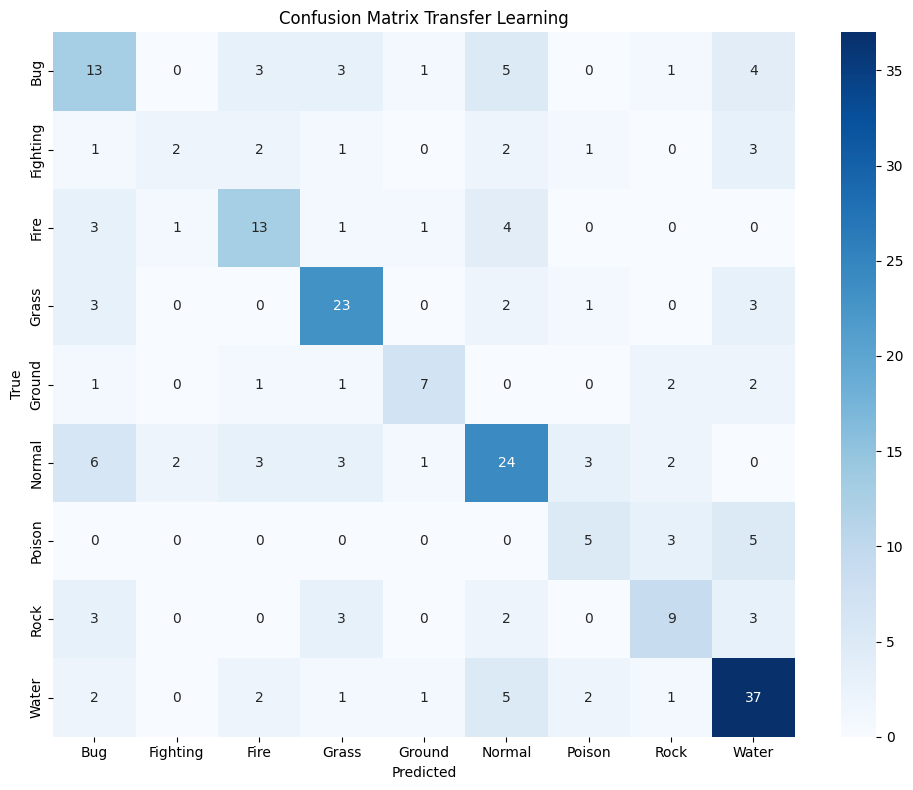

In [24]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.title("Confusion Matrix Transfer Learning")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix_tl.png", dpi=150)
plt.show()

### **Learning Curves**

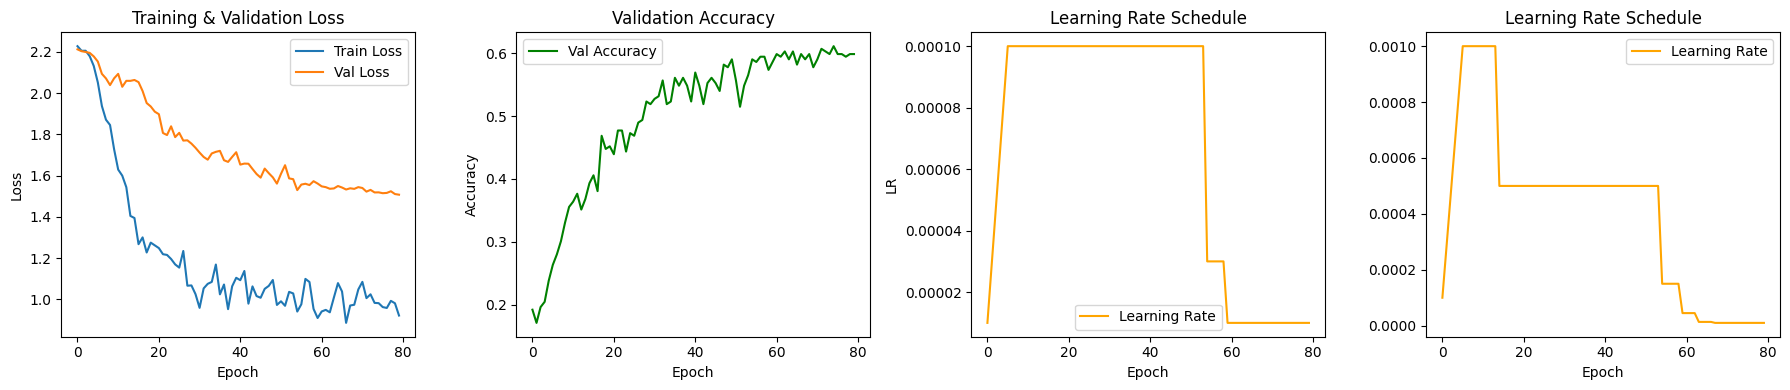

In [25]:
# Training curves
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(history_aug['train_loss'], label='Train Loss')
axes[0].plot(history_aug['val_loss'],   label='Val Loss')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()

axes[1].plot(history_aug['val_acc'], color='green', label='Val Accuracy')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend()

axes[2].plot(history_aug['lr_backbone'], color='orange', label='Learning Rate')
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].set_title("Learning Rate Schedule")
axes[2].legend()

axes[3].plot(history_aug['lr_head'], color='orange', label='Learning Rate')
axes[3].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[3].set_title("Learning Rate Schedule")
axes[3].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

# **Kaggle Submission**

In [ ]:
## Load best checkpoint
model_aug.load_state_dict(torch.load(CHECKPOINT_AUG))
model_aug.eval()

# Test transform must match val_test_transform exactly
test_transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert('RGB')),
    transforms.Resize(256),
    transforms.CenterCrop(img_size),          # 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean,  # [0.485, 0.456, 0.406]
                         std=imagenet_std),   # [0.229, 0.224, 0.225]
])

test_dataset = CID.CustomImageDataset(
    img_dir=f'{BASE}/test/',
    transform=test_transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=64, shuffle=False)

predictions = []
with torch.no_grad():
    for images, ids in test_loader:
        images  = images.to(device)
        outputs = model_aug(images)
        preds   = outputs.argmax(1).cpu()
        for id_, pred in zip(ids, preds):
            predictions.append({
                'Id':    id_,
                'label': train_dataset.classes[pred.item()]
            })

# Create submission CSV
submission_df = pd.DataFrame(predictions)
submission_df = submission_df.sort_values('Id')
submission_df.to_csv(f'{BASE}/submission_n2.csv', index=False)
print(submission_df.head(10))
print(f"\nTotal predictions: {len(submission_df)}")

                                     Id     label
0  0020aec0-f6b6-4672-b60a-bcfe05d16431    Normal
1  005c1fab-6223-40ed-9b27-e64b519a4412      Rock
2  01470d4e-218d-4ba9-9a40-c3dc3f7e85c8      Rock
3  0180f914-baae-4b13-ae34-5e288e861de4    Poison
4  0268167e-10e8-46a6-9809-3cb58520404e     Grass
5  03af91cb-17c8-4b95-8ea0-8e58b9d31e36       Bug
6  03efe05e-c6ba-4bbc-9462-ad467a3d7408    Normal
7  046e952b-fc8a-4e25-8b2c-8359df12edbb       Bug
8  04ce5005-7a7c-4379-a198-7985c3f6905c  Fighting
9  04e52b48-797f-41cf-9f8d-852b4a10d2f3    Normal

Total predictions: 300
